# U.S. Treasury Yield-Curve PCA, Forecast Validation & Linear Risk Mapping

**Version 3.3.0 | controlled deterministic research notebook | frozen default run**

This notebook separates three questions that are often incorrectly conflated:

1. **Risk representation:** which orthogonal yield-curve shock directions explain historical covariance?
2. **Forecasting:** can past factor dynamics beat an unchanged-curve benchmark out of sample?
3. **Portfolio relevance:** how do key-rate DV01s convert curve shocks into dollar P&L and residual risk?

Repository scope is restricted historical U.S. Treasury CMT research, model challenge, and illustrative linear KRD diagnostics. `SHARE WITH CAVEATS` is a technical disposition—not organizational model approval, production authorization, or management acceptance of risk. This is **not** a SOFR/OIS pricing curve, full-revaluation engine, limit model, trading signal, or VaR/FRTB capital implementation.


## 0. Setup and configuration

Upload this notebook by itself to Colab and choose **Runtime → Run all**. The notebook carries a hash-verified, offline runtime containing the exact model implementation and frozen data snapshot, so no repository clone, network download, or project installation is required. When the complete repository is present, the notebook instead binds to its matching `src/` and `data/` files. `YIELD_CURVE_PCA_PROJECT_ROOT` may explicitly select that repository.


In [1]:
from base64 import b64decode
from hashlib import sha256
from io import BytesIO
from pathlib import Path, PurePosixPath
import os
import sys
from tempfile import TemporaryDirectory
from time import perf_counter
from zipfile import BadZipFile, ZipFile

runtime_python_version = sys.version_info[:2]
if runtime_python_version < (3, 10):
    raise RuntimeError(
        "This release requires Python 3.10 or newer. "
        "Select a compatible Colab or Jupyter runtime."
    )
runtime_validation_status = (
    "validated Python runtime"
    if runtime_python_version < (3, 14)
    else "newer-than-validated Python runtime; guarded execution"
)

try:
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import scipy
    from IPython import get_ipython
    from IPython.display import Markdown, display
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "The notebook requires numpy, pandas, scipy, matplotlib, and IPython. "
        "A standard Google Colab Python runtime includes these dependencies."
    ) from exc

ipython_shell = get_ipython()
if ipython_shell is not None:
    ipython_shell.run_line_magic("matplotlib", "inline")

configured_root = os.environ.get("YIELD_CURVE_PCA_PROJECT_ROOT")
def repository_layout_is_complete(path):
    return (
        (path / "src/yield_curve_pca").is_dir()
        and (path / "data/h15_treasury_cmt_2000_2025.csv.gz").is_file()
        and (path / "data/source_manifest.json").is_file()
    )


if configured_root is not None and not repository_layout_is_complete(Path(configured_root).expanduser()):
    raise FileNotFoundError(
        "YIELD_CURVE_PCA_PROJECT_ROOT does not contain the complete src and data layout: "
        + configured_root
    )
root_candidates = [
    *([Path(configured_root).expanduser()] if configured_root else []),
    Path.cwd(),
    *Path.cwd().parents,
]
PROJECT_ROOT = next(
    (path.resolve() for path in root_candidates if repository_layout_is_complete(path)),
    None,
)

EXPECTED_EMBEDDED_RUNTIME_SHA256 = "5c680a2e6bc2ee1adced3677a3a27b15d4f74097dc0590d9ce3cf4bd66fc0661"
EXPECTED_EMBEDDED_RUNTIME_MEMBERS = (
    'src/yield_curve_pca/__init__.py',
    'src/yield_curve_pca/__main__.py',
    'src/yield_curve_pca/cli.py',
    'src/yield_curve_pca/config.py',
    'src/yield_curve_pca/data.py',
    'src/yield_curve_pca/forecast.py',
    'src/yield_curve_pca/pca.py',
    'src/yield_curve_pca/pipeline.py',
    'src/yield_curve_pca/reporting.py',
    'src/yield_curve_pca/resources/__init__.py',
    'src/yield_curve_pca/resources/h15_treasury_cmt_2000_2025.csv.gz',
    'src/yield_curve_pca/resources/source_manifest.json',
    'src/yield_curve_pca/risk.py',
    'src/yield_curve_pca/validation.py',
)
EMBEDDED_RUNTIME_CHUNKS = (
    '...',
    'JsECAAAA',
)
MAX_EMBEDDED_RUNTIME_ARCHIVE_BYTES = 2_000_000
MAX_EMBEDDED_RUNTIME_EXPANDED_BYTES = 4_000_000

RUNTIME_DIRECTORY = None
if PROJECT_ROOT is not None:
    RUNTIME_MODE = "repository"
    PACKAGE_ROOT = PROJECT_ROOT / "src/yield_curve_pca"
    SNAPSHOT_PATH = PROJECT_ROOT / "data/h15_treasury_cmt_2000_2025.csv.gz"
    PIPELINE_PROJECT_ROOT = PROJECT_ROOT
else:
    RUNTIME_MODE = "standalone embedded"
    runtime_payload = b64decode("".join(EMBEDDED_RUNTIME_CHUNKS), validate=True)
    if len(runtime_payload) > MAX_EMBEDDED_RUNTIME_ARCHIVE_BYTES:
        raise RuntimeError("Embedded runtime archive exceeds its size control.")
    if sha256(runtime_payload).hexdigest() != EXPECTED_EMBEDDED_RUNTIME_SHA256:
        raise RuntimeError("Embedded runtime archive failed SHA-256 validation.")
    RUNTIME_DIRECTORY = TemporaryDirectory(prefix="yield_curve_pca_v330_")
    runtime_root = Path(RUNTIME_DIRECTORY.name).resolve()
    try:
        with ZipFile(BytesIO(runtime_payload)) as archive:
            members = archive.infolist()
            observed_member_names = tuple(member.filename for member in members)
            if observed_member_names != EXPECTED_EMBEDDED_RUNTIME_MEMBERS:
                raise RuntimeError("Embedded runtime archive member contract failed.")
            if sum(member.file_size for member in members) > MAX_EMBEDDED_RUNTIME_EXPANDED_BYTES:
                raise RuntimeError("Embedded runtime archive exceeds its expanded-size control.")
            for member in members:
                relative = PurePosixPath(member.filename)
                if relative.is_absolute() or not relative.parts or ".." in relative.parts:
                    raise RuntimeError("Embedded runtime archive contains an unsafe path.")
                destination = runtime_root.joinpath(*relative.parts).resolve()
                if runtime_root not in destination.parents:
                    raise RuntimeError("Embedded runtime extraction escaped its temporary directory.")
                destination.parent.mkdir(parents=True, exist_ok=True)
                destination.write_bytes(archive.read(member))
    except BadZipFile as exc:
        raise RuntimeError("Embedded runtime archive is invalid.") from exc
    PACKAGE_ROOT = runtime_root / "src/yield_curve_pca"
    SNAPSHOT_PATH = PACKAGE_ROOT / "resources/h15_treasury_cmt_2000_2025.csv.gz"
    PIPELINE_PROJECT_ROOT = None

loaded_package_modules = [
    name for name in sys.modules if name == "yield_curve_pca" or name.startswith("yield_curve_pca.")
]
for module_name in loaded_package_modules:
    del sys.modules[module_name]
package_source_parent = str(PACKAGE_ROOT.parent)
sys.path = [entry for entry in sys.path if entry != package_source_parent]
sys.path.insert(0, package_source_parent)

from yield_curve_pca import DataConfig, ForecastConfig, PCAConfig, PipelineConfig, RiskConfig
from yield_curve_pca.pipeline import run_pipeline
from yield_curve_pca.reporting import (
    format_table,
    plot_curve_history,
    plot_forecast_rmse,
    plot_pca_structure,
    plot_rolling_stability,
    plot_variance_reconciliation,
)
from yield_curve_pca.risk import map_linear_curve_risk

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
dependency_versions = (
    runtime_validation_status
    + " | Python " + ".".join(map(str, sys.version_info[:3]))
    + " | NumPy " + np.__version__
    + " | pandas " + pd.__version__
    + " | SciPy " + scipy.__version__
    + " | Matplotlib " + matplotlib.__version__
)
display(Markdown(
    "**Runtime ready:** " + RUNTIME_MODE + "; " + dependency_versions
    + ". Exact implementation and snapshot checks follow."
))


**Runtime ready:** standalone embedded; validated Python runtime | Python 3.13.14 | NumPy 2.5.2 | pandas 2.3.3 | SciPy 1.18.1 | Matplotlib 3.11.1. Exact implementation and snapshot checks follow.

In [2]:
from hashlib import sha256

EXPECTED_IMPLEMENTATION_SHA256 = "00bacee9e61bfb8d44ee268a48ea7ed0e3cca722ae68d41085d3d0d9794e9887"
EXPECTED_SNAPSHOT_COMPRESSED_SHA256 = "910dab1695a286a242d4d8832838938dc3cbec1795d048c6eaebb14c5ae4f08e"

package_root = PACKAGE_ROOT
implementation_digest = sha256()
for source in sorted(package_root.rglob("*.py")):
    relative = source.relative_to(package_root).as_posix().encode("utf-8")
    implementation_digest.update(len(relative).to_bytes(4, "big"))
    implementation_digest.update(relative)
    implementation_digest.update(source.read_bytes())
observed_implementation_sha256 = implementation_digest.hexdigest()
observed_snapshot_sha256 = sha256(SNAPSHOT_PATH.read_bytes()).hexdigest()
assert observed_implementation_sha256 == EXPECTED_IMPLEMENTATION_SHA256
assert observed_snapshot_sha256 == EXPECTED_SNAPSHOT_COMPRESSED_SHA256
display(Markdown(
    "**Execution binding verified (" + RUNTIME_MODE + "):** implementation `" + observed_implementation_sha256
    + "`; compressed snapshot `" + observed_snapshot_sha256 + "`."
))


**Execution binding verified (standalone embedded):** implementation `00bacee9e61bfb8d44ee268a48ea7ed0e3cca722ae68d41085d3d0d9794e9887`; compressed snapshot `910dab1695a286a242d4d8832838938dc3cbec1795d048c6eaebb14c5ae4f08e`.

In [3]:
CONFIG = PipelineConfig(
    data=DataConfig(
        start_date="2000-01-01",
        end_date="2025-12-31",
        source_mode="snapshot",
        weekly_rule="W-FRI",
        boundary_week_policy="drop",
        maximum_staleness_days=None,
    ),
    pca=PCAConfig(
        retained_factors=3,
        minimum_template_similarity=0.70,
        minimum_template_dominance_margin=0.10,
        current_halflife_weeks=52.0,
        rolling_window_years=5,
        bootstrap_replications=2_000,
        bootstrap_block_weeks=13,
        random_seed=20260825,
    ),
    forecast=ForecastConfig(
        enabled=True,
        minimum_training_weeks=520,
        retained_factors=3,
        hac_lags=4,
        minimum_model_selection_observations=52,
        confirmation_observations=52,
        interval_evaluation_observations=260,
        interval_history_weeks=260,
        minimum_interval_observations=104,
        interval_bootstrap_replications=20_000,
        interval_bootstrap_block_lengths=(4, 13, 26),
        adoption_alpha=0.05,
        minimum_rmse_improvement=0.01,
    ),
    risk=RiskConfig(
        historical_window_weeks=520,
        var_confidence=0.99,
        es_confidence=0.975,
    ),
)

ILLUSTRATIVE_KRD_USD_PER_BP = pd.Series(
    {
        "3M": 0.0, "6M": 0.0, "1Y": 25_000.0, "2Y": 100_000.0,
        "3Y": 150_000.0, "5Y": 200_000.0, "7Y": 150_000.0,
        "10Y": 100_000.0, "20Y": 50_000.0,
    },
    name="DV01 (USD per bp fall in yield)",
)

started = perf_counter()
RESULT = run_pipeline(CONFIG, project_root=PIPELINE_PROJECT_ROOT)
RUNTIME_SECONDS = perf_counter() - started
display(Markdown(
    f"**Pipeline completed:** {RUNTIME_SECONDS:.2f} seconds  |  "
    f"**data mode:** {RESULT.data.provenance.mode}"
))


**Pipeline completed:** 27.31 seconds  |  **data mode:** SNAPSHOT

## tl;dr


In [4]:
pca = RESULT.structural_pca
warnings_count = int((RESULT.data.quality_table["status"] == "WARN").sum())
max_angle = RESULT.rolling_stability["Maximum principal angle (deg)"].max()
sequential_worst = RESULT.sequential_stability["Maximum principal angle (deg)"].max()
sequential_latest = RESULT.sequential_stability["Maximum principal angle (deg)"].iloc[-1]
forecast_decision = RESULT.forecast_note if RESULT.forecast is None else RESULT.forecast.selected_model
partition_text = "not run"
if RESULT.forecast is not None:
    partition_counts = RESULT.forecast.audit_trail["Evaluation partition"].value_counts()
    partition_text = (
        f"{partition_counts.get('Selection', 0)} selection / "
        f"{partition_counts.get('Confirmation', 0)} confirmation / "
        f"{partition_counts.get('Interval evaluation', 0)} interval-evaluation"
    )
coverage_warning = (
    "not evaluated"
    if RESULT.forecast is None
    else (
        f"{(RESULT.forecast.interval_coverage['Status'] == 'INCONCLUSIVE').sum()} of "
        f"{len(RESULT.forecast.interval_coverage)} gates INCONCLUSIVE; "
        f"minimum independent gap {RESULT.forecast.interval_coverage['Coverage gap'].min():.1%}"
    )
)

summary = f"""
### Executive result

- The controlled weekly sample contains **{len(RESULT.data.weekly_changes_bp):,}** change observations from **{RESULT.data.weekly_changes_bp.index.min().date()}** to **{RESULT.data.weekly_changes_bp.index.max().date()}**, supported by the baseline level curve on **{RESULT.data.weekly_yields_pct.index.min().date()}**. It is one frozen/latest-revised history—not a point-in-time vintage panel—and is stale for current decisions.
- The first three covariance PCs explain **{pca.explained_ratio[:3].sum():.2%}** of equal-tenor historical curve-change variance. Template similarity is **{pca.template_similarity[0]:.3f} / {pca.template_similarity[1]:.3f} / {pca.template_similarity[2]:.3f}** and dominance margin is **{pca.template_dominance_margin[0]:.3f} / {pca.template_dominance_margin[1]:.3f} / {pca.template_dominance_margin[2]:.3f}**.
- Compression does **not** prove factor stability: retrospective full-sample-reference worst angle is **{max_angle:.1f}°**; chronologically separated adjacent-window worst/latest are **{sequential_worst:.1f}° / {sequential_latest:.1f}°**. Historical evidence rejects a universally stable factor-limit taxonomy.
- Walk-forward adoption uses disjoint **{partition_text}** observations and selects **{forecast_decision}** as the fallback benchmark; no PCA challenger passed both economic and one-sided Clark–West gates.
- Marginal-band calibration is **{coverage_warning}**. Familywise block-bootstrap coverage inference is not a simultaneous curve band and does not authorize limit use.
- Numerical validation is **{RESULT.validation.overall_assessment}**; the data layer reports **{warnings_count}** review items. Warnings are visible controls, not silently converted into PASS.

**Repository-scope disposition:** restricted historical research and illustrative linear KRD diagnostics only. Factor limits, current risk, official VaR/ES, hedge sizing, trading, capital, and management forecasting are **NOT ELIGIBLE**. External owner, validation, approval, entitlement, and data-vintage controls remain prerequisites.
"""
display(Markdown(summary))



### Executive result

- The controlled weekly sample contains **1,355** change observations from **2000-01-14** to **2025-12-26**, supported by the baseline level curve on **2000-01-07**. It is one frozen/latest-revised history—not a point-in-time vintage panel—and is stale for current decisions.
- The first three covariance PCs explain **96.87%** of equal-tenor historical curve-change variance. Template similarity is **0.948 / 0.949 / 0.932** and dominance margin is **0.679 / 0.675 / 0.778**.
- Compression does **not** prove factor stability: retrospective full-sample-reference worst angle is **71.2°**; chronologically separated adjacent-window worst/latest are **73.9° / 9.3°**. Historical evidence rejects a universally stable factor-limit taxonomy.
- Walk-forward adoption uses disjoint **523 selection / 52 confirmation / 260 interval-evaluation** observations and selects **No-change benchmark** as the fallback benchmark; no PCA challenger passed both economic and one-sided Clark–West gates.
- Marginal-band calibration is **18 of 18 gates INCONCLUSIVE; minimum independent gap -11.5%**. Familywise block-bootstrap coverage inference is not a simultaneous curve band and does not authorize limit use.
- Numerical validation is **SHARE WITH CAVEATS**; the data layer reports **5** review items. Warnings are visible controls, not silently converted into PASS.

**Repository-scope disposition:** restricted historical research and illustrative linear KRD diagnostics only. Factor limits, current risk, official VaR/ES, hedge sizing, trading, capital, and management forecasting are **NOT ELIGIBLE**. External owner, validation, approval, entitlement, and data-vintage controls remain prerequisites.


## 1. Context & methods

### Key assumptions

- H.15 constant-maturity yields are nominal Treasury **par-yield risk proxies**, not tradable zero rates or collateralized derivatives discount factors.
- The primary PCA uses same-date complete curves and weekly changes in basis points: $\Delta y_{t,i}=100(y_{t,i}-y_{t-1,i})$ because H.15 observations are quoted in percent.
- For $X\in\mathbb{R}^{T\times p}$, $\Sigma=V\Lambda V^\top$ and factor scores are $F=(X-\mu)V$. Unit-norm eigenvectors $V$, one-standard-deviation shocks $V\sqrt{\Lambda}$, and tenor-factor correlations are reported separately.
- PCA is a covariance representation, not a forecast. Forecast models are re-estimated at every origin using only information available before the target week.
- Positive DV01 means price increases when yield falls 1 bp, so linear P&L is $\Delta P\approx-d^\top\Delta y_{bp}$.
- Chronological row splits prevent future-row leakage, but the frozen/latest-revised source is not a historical vintage archive; revision look-ahead remains possible.


## 2. Data, provenance & quality


In [5]:
provenance = pd.DataFrame([RESULT.data.provenance.to_dict()]).T
provenance.columns = ["Value"]
display(format_table(provenance, caption="Run-level data provenance"))

quality = RESULT.data.quality_table.copy()
display(format_table(quality, caption="Data-quality controls and decision impact"))

gap_distribution = (
    RESULT.data.observation_gap_days.value_counts().sort_index().rename("Weekly changes").to_frame()
)
gap_distribution.index.name = "Calendar gap (days)"
display(format_table(gap_distribution, formats={"Weekly changes": "{:,.0f}"}, caption="Actual weekly observation horizons"))


,Value
mode,SNAPSHOT
requested_start,2000-01-01
requested_end,2025-12-31
observed_start,2000-01-03
observed_end,2025-12-31
loaded_at_utc,2026-08-26T06:11:08+00:00
source_acquired_at_utc,2026-08-25T00:00:00+00:00
source_as_of_date,2025-12-31
content_sha256,413b0d1241454a45d45d4bf258aa2fdf079eb4455602d102d4c3af710d306e13
source_payload_sha256,413b0d1241454a45d45d4bf258aa2fdf079eb4455602d102d4c3af710d306e13


,control,status,result,threshold,risk
0,"Unique, ordered daily dates",PASS,duplicates=0,zero duplicates; ascending dates,Duplicate or unordered dates corrupt returns and time-series splits.
1,Complete synchronized weekly panel,PASS,weekly_nulls=0; change_nulls=0,zero,Incomplete curves change the covariance universe through time.
2,Minimum estimation history,PASS,"1,355 weekly changes",>=260,An undersized history makes eigenvectors and tail metrics unstable.
3,Requested start-date coverage,PASS,first_complete_daily_curve=2000-01-03; lag=2 calendar days,0 to 7 days,A late-starting source can silently shorten the requested calibration history.
4,Requested end-date coverage,PASS,last=2025-12-26; lag=5 calendar days,0 to 7 days,A truncated cache can masquerade as a complete requested sample.
5,Final weekly observation coverage,PASS,last=2025-12-26; within-week lag=0 days,0 to 1 days,A cache can reach the requested week yet omit its latest eligible observation.
6,Eligible weekly-period coverage,PASS,observed=2000-01-01/2000-01-07 to 2025-12-20/2025-12-26; expected=2000-01-01/2000-01-07 to 2025-12-20/2025-12-26,first and final eligible weekly periods present,A missing boundary period silently changes the calibration window.
7,Weekly observation gaps,PASS,max=8 days; excessive=0,no gap > 12 days,Long gaps mix risk horizons and inflate observed changes.
8,Nominal weekly-horizon consistency,WARN,non-7-day changes=76 of 1355; range=6-8 days,review every non-7-day interval,Holiday rolls and partial periods create slightly different risk horizons.
9,Boundary-week completeness,PASS,included partial boundaries=none; policy=drop,no partial boundary week in the estimation sample,Partial boundary weeks have a shorter market-information horizon.


,Weekly changes
Calendar gap (days),
6.000000,38
7.000000,"1,279"
8.000000,38


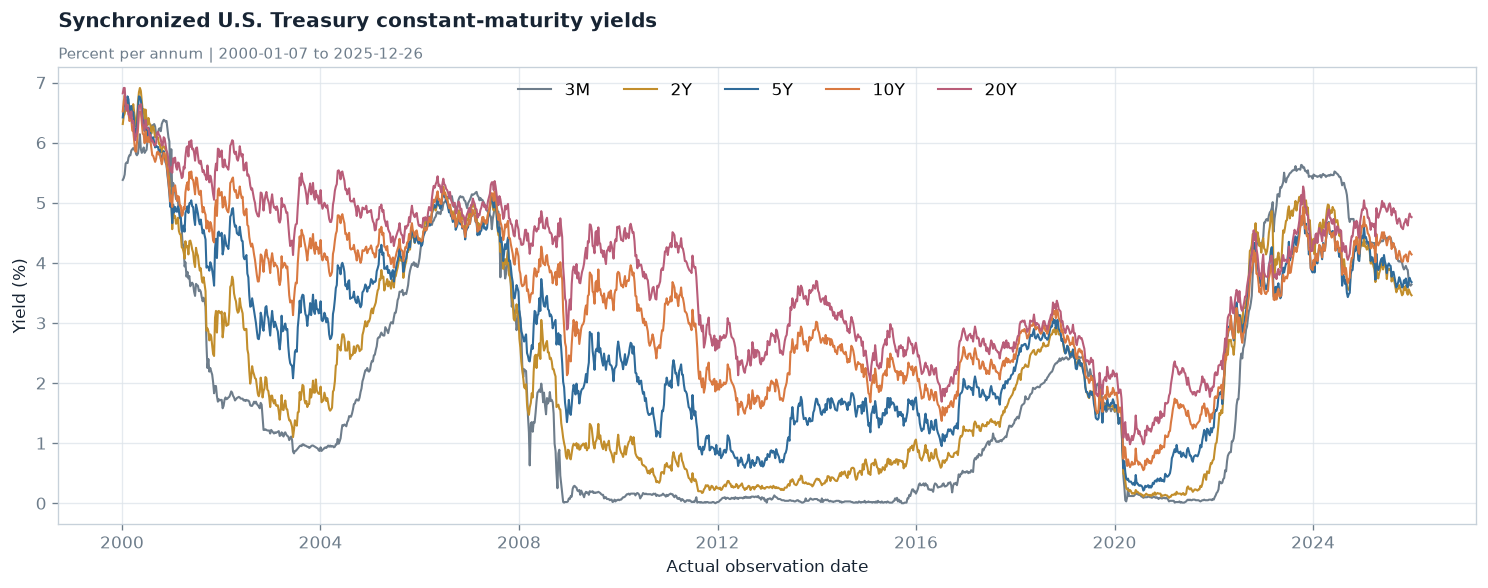

In [6]:
fig = plot_curve_history(RESULT.data.weekly_yields_pct)
display(fig)
plt.close(fig)


## 3. Structural and recency-weighted PCA


In [7]:
components = []
for index, name in enumerate(pca.component_names):
    components.append(
        {
            "Component": name,
            "Economic shape": pca.assigned_shapes[index] if index < 3 else "Residual",
            "Suggested shape": pca.suggested_shapes[index] if index < 3 else "—",
            "Identification": pca.identification_status[index] if index < 3 else "—",
            "Eigenvalue": pca.eigenvalues[index],
            "Variance share": pca.explained_ratio[index],
            "Cumulative share": pca.explained_ratio[: index + 1].sum(),
            "Template similarity": pca.template_similarity[index] if index < 3 else np.nan,
            "Template dominance margin": pca.template_dominance_margin[index] if index < 3 else np.nan,
        }
    )
component_table = pd.DataFrame(components).set_index("Component")
display(format_table(
    component_table,
    formats={
        "Eigenvalue": "{:.3f}", "Variance share": "{:.2%}",
        "Cumulative share": "{:.2%}", "Template similarity": "{:.3f}",
        "Template dominance margin": "{:.3f}",
    },
    caption="Structural covariance PCA | eigenvalues in bp²",
))

display(format_table(pca.loading_table(3), formats="{:+.4f}", caption="Unit-norm eigenvectors V"))
display(format_table(pca.sigma_shock_table(3), formats="{:+.2f}", caption="One-standard-deviation physical curve shocks V√Λ (bp)"))
display(format_table(pca.tenor_factor_correlation(3), formats="{:+.3f}", caption="Tenor-to-factor correlations"))


,Economic shape,Suggested shape,Identification,Eigenvalue,Variance share,Cumulative share,Template similarity,Template dominance margin
Component,,,,,,,,
PC1 — Level,Level,Level,IDENTIFIED,881.705,77.62%,77.62%,0.948,0.679
PC2 — Slope,Slope,Slope,IDENTIFIED,159.332,14.03%,91.65%,0.949,0.675
PC3 — Curvature,Curvature,Curvature,IDENTIFIED,59.213,5.21%,96.87%,0.932,0.778
PC4 — Residual,Residual,—,—,16.177,1.42%,98.29%,—,—
PC5 — Residual,Residual,—,—,8.078,0.71%,99.00%,—,—
PC6 — Residual,Residual,—,—,5.134,0.45%,99.45%,—,—
PC7 — Residual,Residual,—,—,2.615,0.23%,99.68%,—,—
PC8 — Residual,Residual,—,—,2.150,0.19%,99.87%,—,—
PC9 — Residual,Residual,—,—,1.450,0.13%,100.00%,—,—


,PC1 — Level,PC2 — Slope,PC3 — Curvature
3M,+0.1249,-0.5803,-0.5184
6M,+0.1631,-0.4659,-0.1982
1Y,+0.2376,-0.4035,+0.0917
2Y,+0.3521,-0.1987,+0.4536
3Y,+0.3933,-0.0810,+0.3865
5Y,+0.4232,+0.0936,+0.1448
7Y,+0.4213,+0.2093,-0.0720
10Y,+0.3902,+0.2710,-0.2720
20Y,+0.3374,+0.3338,-0.4779


,PC1 — Level,PC2 — Slope,PC3 — Curvature
3M,+3.71,-7.32,-3.99
6M,+4.84,-5.88,-1.53
1Y,+7.06,-5.09,+0.71
2Y,+10.45,-2.51,+3.49
3Y,+11.68,-1.02,+2.97
5Y,+12.56,+1.18,+1.11
7Y,+12.51,+2.64,-0.55
10Y,+11.59,+3.42,-2.09
20Y,+10.02,+4.21,-3.68


,PC1 — Level,PC2 — Slope,PC3 — Curvature
3M,+0.394,-0.778,-0.423
6M,+0.596,-0.724,-0.188
1Y,+0.772,-0.557,+0.077
2Y,+0.915,-0.220,+0.306
3Y,+0.958,-0.084,+0.244
5Y,+0.981,+0.092,+0.087
7Y,+0.969,+0.205,-0.043
10Y,+0.940,+0.278,-0.170
20Y,+0.859,+0.361,-0.315


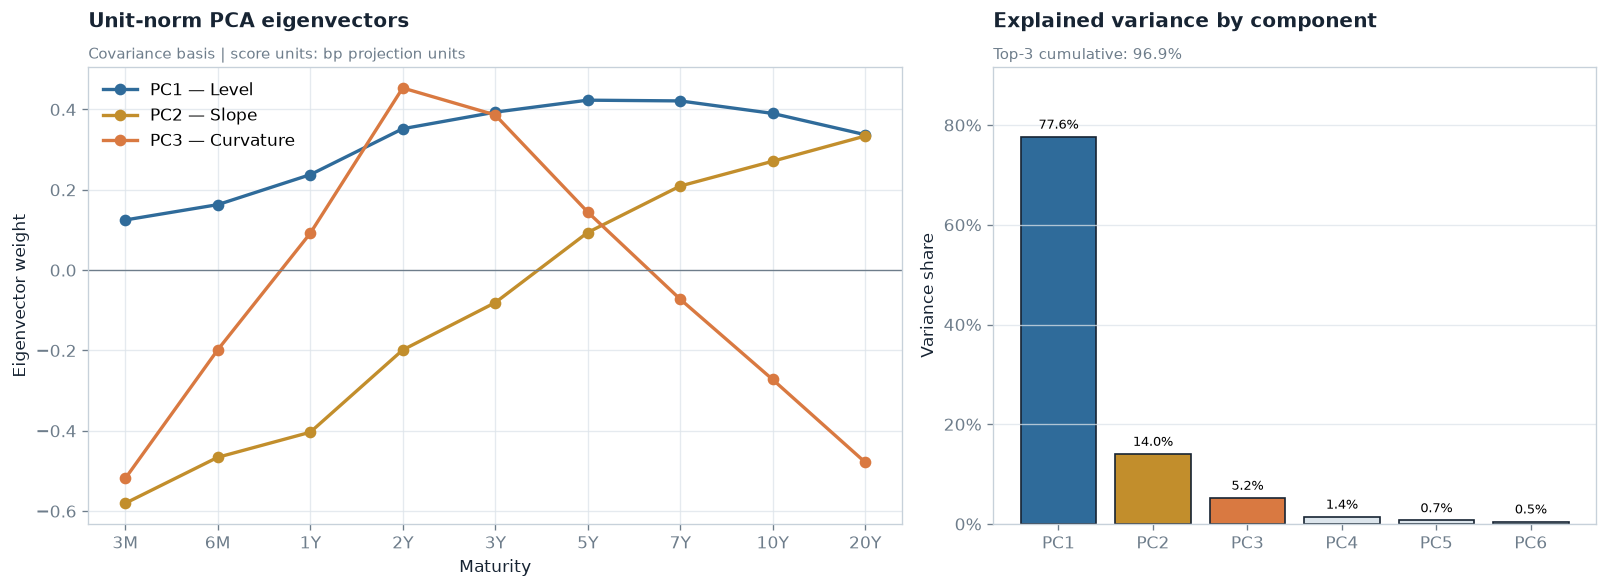

In [8]:
fig = plot_pca_structure(pca, CONFIG.pca.retained_factors)
display(fig)
plt.close(fig)


In [9]:
current = RESULT.current_ewma_pca
current_comparison = pd.DataFrame(
    {
        "Structural variance share": pca.explained_ratio[:3],
        "Current EWMA variance share": current.explained_ratio[:3],
        "Structural shape": pca.assigned_shapes,
        "Current shape": current.assigned_shapes,
        "Current identification": current.identification_status,
        "Current template similarity": current.template_similarity,
        "Current template dominance margin": current.template_dominance_margin,
    },
    index=["PC1", "PC2", "PC3"],
)
display(format_table(
    current_comparison,
    formats={
        "Structural variance share": "{:.2%}",
        "Current EWMA variance share": "{:.2%}",
        "Current template similarity": "{:.3f}",
        "Current template dominance margin": "{:.3f}",
    },
    caption=f"Structural versus recency-weighted PCA as of {current.training_end.date()} | EWMA effective n={current.effective_observations:.1f}",
))
display(format_table(
    RESULT.structural_current_ewma_comparison,
    formats={
        "Physical loading cosine": "{:.4f}",
        "Ordered subspace principal angle (deg)": "{:.3f}",
        "Reference one-sigma norm (bp)": "{:.3f}",
        "Candidate one-sigma norm (bp)": "{:.3f}",
        "Candidate/reference sigma ratio": "{:.4f}",
    },
    caption=(
        "Structural versus current-EWMA absolute factor shocks | "
        "candidate aligned to structural physical coordinates"
    ),
))


,Structural variance share,Current EWMA variance share,Structural shape,Current shape,Current identification,Current template similarity,Current template dominance margin
PC1,77.62%,84.81%,Level,Level,IDENTIFIED,0.933,0.649
PC2,14.03%,9.34%,Slope,Slope,IDENTIFIED,0.925,0.680
PC3,5.21%,3.68%,Curvature,Curvature,IDENTIFIED,0.906,0.645


,Reference factor,Candidate matched factor,Physical loading cosine,Ordered subspace principal angle (deg),Reference one-sigma norm (bp),Candidate one-sigma norm (bp),Candidate/reference sigma ratio,Reference observations,Candidate observations,Reference start,Reference end,Candidate start,Candidate end
Factor rank,,,,,,,,,,,,,
1,PC1 — Level,PC1 — Level,0.9969,1.117,29.694,31.005,1.0442,1355,1355,2000-01-14 00:00:00,2025-12-26 00:00:00,2000-01-14 00:00:00,2025-12-26 00:00:00
2,PC2 — Slope,PC2 — Slope,0.9850,4.538,12.623,10.290,0.8152,1355,1355,2000-01-14 00:00:00,2025-12-26 00:00:00,2000-01-14 00:00:00,2025-12-26 00:00:00
3,PC3 — Curvature,PC3 — Curvature,0.9812,5.598,7.695,6.457,0.8391,1355,1355,2000-01-14 00:00:00,2025-12-26 00:00:00,2000-01-14 00:00:00,2025-12-26 00:00:00


## 4. Reconstruction, specification challenge & model stability


In [10]:
display(format_table(RESULT.reconstruction_summary, formats={"Value (bp)": "{:.4f}"}, caption="In-sample reconstruction controls"))
display(format_table(RESULT.reconstruction_by_tenor, formats="{:.3f}", caption="In-sample top-3 residual by tenor"))
display(format_table(RESULT.oos_reconstruction_metrics, formats="{:.3f}", caption="Strictly out-of-time top-3 reconstruction by tenor"))
assert (RESULT.oos_reconstruction_audit["Training end"] < RESULT.oos_reconstruction_audit.index).all()
oos_audit_excerpt = pd.concat(
    [RESULT.oos_reconstruction_audit.head(3), RESULT.oos_reconstruction_audit.tail(3)]
)
display(format_table(
    oos_audit_excerpt,
    formats={"Target position": "{:,.0f}", "Basis refit sequence": "{:,.0f}",
             "Basis refit trigger position": "{:,.0f}", "Maximum source position": "{:,.0f}",
             "Training observations": "{:,.0f}"},
    caption="OOS basis-vintage audit excerpt | every training end precedes its target",
))

challenge_formats = {
    "Effective observations": "{:.1f}", "PC1": "{:.2%}", "PC2": "{:.2%}",
    "PC3": "{:.2%}", "Top-3 cumulative": "{:.2%}", "Minimum template similarity": "{:.3f}",
    "Minimum template dominance margin": "{:.3f}",
}
display(format_table(RESULT.specification_challenge, formats=challenge_formats, caption="Controlled PCA specification challenge"))
display(format_table(
    RESULT.methodology_sensitivity,
    formats={
        "Physical loading cosine": "{:.3f}",
        "Ordered subspace principal angle (deg)": "{:.2f}",
        "Reference one-sigma norm (bp)": "{:.2f}",
        "Candidate one-sigma norm (bp)": "{:.2f}",
        "Candidate/reference sigma ratio": "{:.3f}",
        "Pre top-3 variance": "{:.2%}",
        "Post top-3 variance": "{:.2%}",
    },
    caption="Pre/post 2021-12-06 Treasury methodology sensitivity (cross-boundary week excluded)",
))
display(Markdown(
    "**Methodology interpretation:** ordered principal angles describe the three-dimensional "
    "subspace as a set; they are not PC-specific Level/Slope/Curvature angles. Matched-factor "
    "identity is assessed separately by physical loading cosine. Market-regime and source-method "
    "effects remain confounded."
))


,Metric,Value (bp)
0,Full-rank maximum absolute error,0.0000
1,Top-3 mean absolute error,1.3421
2,Top-3 root mean squared error,1.9882
3,Top-3 95th percentile absolute error,3.9039
4,Top-3 maximum absolute error,22.7134


,MAE (bp),RMSE (bp),P95 absolute error (bp),Maximum absolute error (bp)
3M,1.557,2.324,4.471,19.444
6M,1.523,2.367,4.536,20.882
1Y,1.865,2.707,5.289,22.713
2Y,1.223,1.655,3.270,8.020
3Y,1.098,1.508,2.836,10.286
5Y,1.359,1.891,3.851,11.502
7Y,1.113,1.671,3.087,22.380
10Y,0.850,1.234,2.420,9.569
20Y,1.491,2.084,4.092,15.256


,MAE (bp),RMSE (bp),P95 absolute error (bp),Maximum absolute error (bp),Holdout observations
3M,1.269,1.788,3.613,9.851,835.000
6M,1.311,1.925,3.899,16.673,835.000
1Y,1.747,2.378,4.881,11.317,835.000
2Y,1.158,1.553,3.033,7.747,835.000
3Y,1.002,1.303,2.574,5.526,835.000
5Y,1.271,1.723,3.534,7.818,835.000
7Y,1.006,1.380,2.600,9.247,835.000
10Y,0.690,0.923,1.922,4.796,835.000
20Y,1.397,1.913,3.608,9.782,835.000


,Target position,Basis refit sequence,Basis refit trigger position,Maximum source position,Training start,Training end,Training observations
Target date,,,,,,,
2009-12-31 00:00:00,520,1,520,519,2000-01-14 00:00:00,2009-12-24 00:00:00,520
2010-01-08 00:00:00,521,1,520,519,2000-01-14 00:00:00,2009-12-24 00:00:00,520
2010-01-15 00:00:00,522,1,520,519,2000-01-14 00:00:00,2009-12-24 00:00:00,520
2025-12-12 00:00:00,"1,352",65,"1,352","1,351",2000-01-14 00:00:00,2025-12-05 00:00:00,"1,352"
2025-12-19 00:00:00,"1,353",65,"1,352","1,351",2000-01-14 00:00:00,2025-12-05 00:00:00,"1,352"
2025-12-26 00:00:00,"1,354",65,"1,352","1,351",2000-01-14 00:00:00,2025-12-05 00:00:00,"1,352"


,Start,End,Tenors,Observations,Effective observations,PC1,PC2,PC3,Top-3 cumulative,Minimum template similarity,Minimum template dominance margin,Control note
Specification,,,,,,,,,,,,
Structural covariance PCA,2000-01-14,2025-12-26,9,1355,1355.0,77.62%,14.03%,5.21%,96.87%,0.932,0.675,Full core history; equal time weights
Structural correlation PCA,2000-01-14,2025-12-26,9,1355,1355.0,71.83%,18.92%,5.46%,96.21%,0.923,0.744,Full core history; tenor volatility standardized
Current EWMA covariance PCA,2000-01-14,2025-12-26,9,1355,150.0,84.81%,9.34%,3.68%,97.83%,0.906,0.645,Full core history; exponentially weighted
Common-period core 9-tenor PCA,2006-02-17,2025-12-26,9,1037,1037.0,76.53%,14.20%,5.86%,96.59%,0.935,0.620,Same rows as the 11-tenor challenge
Common-period extended 11-tenor PCA,2006-02-17,2025-12-26,11,1037,1037.0,64.88%,20.42%,8.28%,93.59%,0.896,0.534,Adds 1M and 30Y on identical rows


,Reference factor,Candidate matched factor,Physical loading cosine,Ordered subspace principal angle (deg),Reference one-sigma norm (bp),Candidate one-sigma norm (bp),Candidate/reference sigma ratio,Reference observations,Candidate observations,Reference start,Reference end,Candidate start,Candidate end,Pre top-3 variance,Post top-3 variance,Status
Factor rank,,,,,,,,,,,,,,,,
1,PC1 — Level,PC1 — Level,0.993,0.99,28.32,36.21,1.279,1143,211,2000-01-14 00:00:00,2021-12-03 00:00:00,2021-12-17 00:00:00,2025-12-26 00:00:00,96.64%,97.88%,EVALUATED
2,PC2 — Slope,PC2 — Slope,0.980,3.50,12.56,12.96,1.032,1143,211,2000-01-14 00:00:00,2021-12-03 00:00:00,2021-12-17 00:00:00,2025-12-26 00:00:00,96.64%,97.88%,EVALUATED
3,PC3 — Curvature,PC3 — Curvature,0.974,7.88,7.46,8.12,1.087,1143,211,2000-01-14 00:00:00,2021-12-03 00:00:00,2021-12-17 00:00:00,2025-12-26 00:00:00,96.64%,97.88%,EVALUATED


**Methodology interpretation:** ordered principal angles describe the three-dimensional subspace as a set; they are not PC-specific Level/Slope/Curvature angles. Matched-factor identity is assessed separately by physical loading cosine. Market-regime and source-method effects remain confounded.

,Window start,Observations,Top-3 variance,Maximum principal angle (deg),Projection distance,Cutoff eigenvalue gap,Minimum template similarity,PC1 loading cosine,PC2 loading cosine,PC3 loading cosine
min,2000-01-14 00:00:00,260.0000,0.9539,3.4690,0.0436,0.1827,0.1935,0.9268,0.3935,0.6756
median,2010-08-16 12:00:00,260.0000,0.9732,8.8354,0.0927,0.6815,0.8909,0.9944,0.9688,0.9678
max,2021-01-08 00:00:00,260.0000,0.9820,71.1730,0.5673,0.8378,0.9456,0.9993,0.9984,0.9973


,2.5%,Median,97.5%,Replications,Block length (weeks),Random seed,Expected order statistics per 2.5% tail,Reference identification status,Reference suggested template
Top-3 variance,0.9631,0.9692,0.9738,"2,000",13,"20,260,825",50.0,,
Maximum principal angle (deg),1.2390,3.0202,7.9689,"2,000",13,"20,260,825",50.0,,
PC1 loading cosine,0.9958,0.9994,1.0000,"2,000",13,"20,260,825",50.0,IDENTIFIED,Level
PC2 loading cosine,0.9750,0.9975,0.9998,"2,000",13,"20,260,825",50.0,IDENTIFIED,Slope
PC3 loading cosine,0.9717,0.9964,0.9996,"2,000",13,"20,260,825",50.0,IDENTIFIED,Curvature


,Replications,Random seed,Expected order statistics per 2.5% tail,Angle median (deg),Angle 97.5% (deg),Top-3 variance median,Top-3 variance 2.5%,Minimum median loading cosine
Block length (weeks),,,,,,,,
4,"2,000",20260825,50.000000,2.65,6.83,96.90%,96.44%,0.997
13,"2,000",20270832,50.000000,3.07,7.95,96.90%,96.31%,0.997
26,"2,000",20280839,50.000000,3.33,9.10,96.94%,96.17%,0.996


**Reference discipline:** the chart below is retrospective against the frozen full-sample basis. It is not a historical alert or point-in-time replay. The adjacent-window table is chronologically separated and uses no rows after each monitoring-window end, but every row comes from one frozen/latest-revised vintage; it is not a point-in-time-vintage replay.

,Reference start,Reference end,Monitoring start,Observations per window,Reference mode,Monitoring top-3 variance,Maximum principal angle (deg),Minimum aligned loading cosine,Factor 1 cosine,Factor 2 cosine,Factor 3 cosine
Monitoring end,,,,,,,,,,,
2009-12-24 00:00:00,2000-01-14 00:00:00,2004-12-31 00:00:00,2005-01-07 00:00:00,260,SEQUENTIAL_PRIOR_NON_OVERLAPPING_WINDOW,95.94%,4.51,0.981,0.997,0.984,0.981
2010-03-26 00:00:00,2000-04-14 00:00:00,2005-04-01 00:00:00,2005-04-08 00:00:00,260,SEQUENTIAL_PRIOR_NON_OVERLAPPING_WINDOW,95.90%,6.14,0.980,0.997,0.986,0.980
2010-06-25 00:00:00,2000-07-14 00:00:00,2005-07-01 00:00:00,2005-07-08 00:00:00,260,SEQUENTIAL_PRIOR_NON_OVERLAPPING_WINDOW,95.96%,6.97,0.978,0.997,0.986,0.978
2010-09-24 00:00:00,2000-10-13 00:00:00,2005-09-30 00:00:00,2005-10-07 00:00:00,260,SEQUENTIAL_PRIOR_NON_OVERLAPPING_WINDOW,95.82%,8.07,0.975,0.996,0.985,0.975
2010-12-23 00:00:00,2001-01-12 00:00:00,2005-12-30 00:00:00,2006-01-06 00:00:00,260,SEQUENTIAL_PRIOR_NON_OVERLAPPING_WINDOW,95.66%,9.64,0.939,0.996,0.950,0.939
2011-03-25 00:00:00,2001-04-12 00:00:00,2006-03-31 00:00:00,2006-04-07 00:00:00,260,SEQUENTIAL_PRIOR_NON_OVERLAPPING_WINDOW,95.67%,10.36,0.926,0.995,0.940,0.926
2011-06-24 00:00:00,2001-07-13 00:00:00,2006-06-30 00:00:00,2006-07-07 00:00:00,260,SEQUENTIAL_PRIOR_NON_OVERLAPPING_WINDOW,95.62%,9.61,0.916,0.995,0.931,0.916
2011-09-23 00:00:00,2001-10-12 00:00:00,2006-09-29 00:00:00,2006-10-06 00:00:00,260,SEQUENTIAL_PRIOR_NON_OVERLAPPING_WINDOW,95.65%,9.03,0.837,0.994,0.844,0.837
2011-12-23 00:00:00,2002-01-11 00:00:00,2006-12-29 00:00:00,2007-01-05 00:00:00,260,SEQUENTIAL_PRIOR_NON_OVERLAPPING_WINDOW,95.64%,7.95,0.811,0.993,0.817,0.811


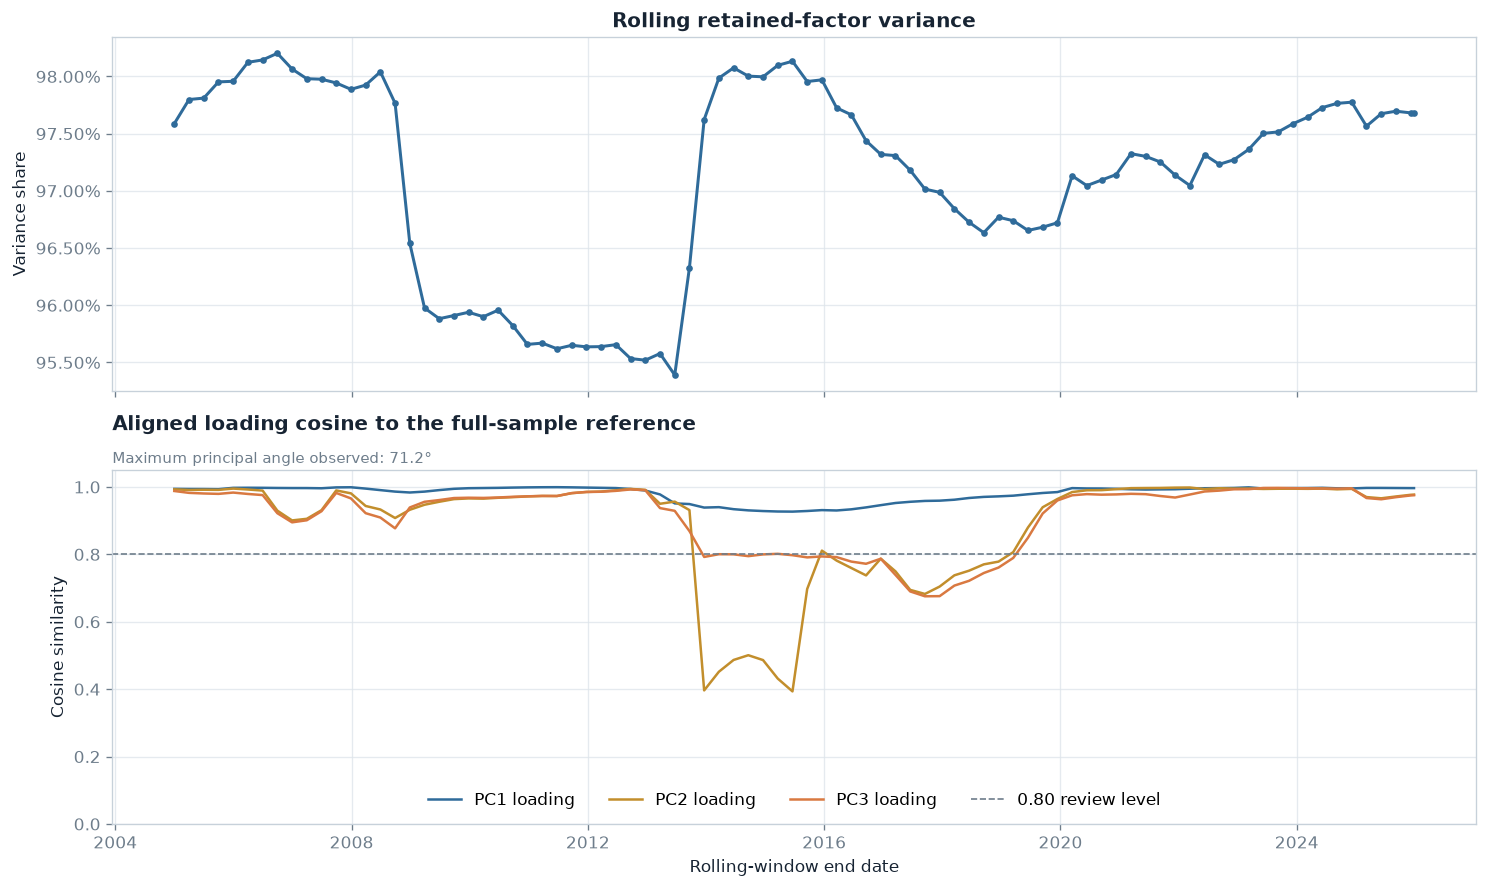

In [11]:
rolling_columns = [
    "Window start", "Observations", "Top-3 variance", "Maximum principal angle (deg)",
    "Projection distance", "Cutoff eigenvalue gap", "Minimum template similarity",
    "PC1 loading cosine", "PC2 loading cosine", "PC3 loading cosine",
]
rolling_summary = RESULT.rolling_stability[rolling_columns].agg(["min", "median", "max"])
display(format_table(
    rolling_summary,
    formats={
        column: "{:.4f}"
        for column in rolling_summary.select_dtypes(include="number").columns
    },
    caption="Quarterly-step five-year loading/subspace stability summary",
))
display(format_table(
    RESULT.bootstrap_stability,
    formats={
        "2.5%": "{:.4f}", "Median": "{:.4f}", "97.5%": "{:.4f}",
        "Replications": "{:,.0f}", "Block length (weeks)": "{:,.0f}",
        "Random seed": "{:,.0f}",
        "Expected order statistics per 2.5% tail": "{:.1f}",
    },
    caption="Circular 13-week block-bootstrap uncertainty",
))
display(format_table(
    RESULT.bootstrap_block_sensitivity,
    formats={
        "Replications": "{:,.0f}", "Angle median (deg)": "{:.2f}",
        "Angle 97.5% (deg)": "{:.2f}", "Top-3 variance median": "{:.2%}",
        "Top-3 variance 2.5%": "{:.2%}", "Minimum median loading cosine": "{:.3f}",
    },
    caption=(
        "Block-length sensitivity — conditional sampling uncertainty only; "
        "rolling windows remain the regime-instability control"
    ),
))
display(Markdown(
    "**Reference discipline:** the chart below is retrospective against the frozen full-sample "
    "basis. It is not a historical alert or point-in-time replay. The adjacent-window table is "
    "chronologically separated and uses no rows after each monitoring-window end, but every row "
    "comes from one frozen/latest-revised vintage; it is not a point-in-time-vintage replay."
))
display(format_table(
    RESULT.sequential_stability,
    formats={
        "Observations per window": "{:,.0f}",
        "Monitoring top-3 variance": "{:.2%}",
        "Maximum principal angle (deg)": "{:.2f}",
        "Minimum aligned loading cosine": "{:.3f}",
        "Factor 1 cosine": "{:.3f}", "Factor 2 cosine": "{:.3f}",
        "Factor 3 cosine": "{:.3f}",
    },
    caption="Sequential adjacent non-overlapping five-year windows (reference end < monitor start)",
))

fig = plot_rolling_stability(
    RESULT.rolling_stability,
    CONFIG.pca.retained_factors,
    loading_cosine_review_level=CONFIG.pca.minimum_loading_cosine_warning,
)
display(fig)
plt.close(fig)


In [12]:
display(format_table(
    RESULT.validation.distribution_checks,
    formats={
        column: "{:.4g}"
        for column in RESULT.validation.distribution_checks.select_dtypes(include="number").columns
    },
    caption="Factor distribution and serial-dependence diagnostics",
))
print(
    "Interpretation: formal skew/kurtosis, Jarque–Bera, and Ljung–Box diagnostics—not the mere "
    "existence of extreme observations—support non-Gaussian and time-varying-risk caveats."
)


,Skewness,Excess kurtosis,Jarque–Bera statistic,Jarque–Bera p-value,Ljung–Box(10) statistic,Ljung–Box(10) p-value,Squared-score LB(10) statistic,Squared-score LB(10) p-value,Status,Interpretation
Factor,,,,,,,,,,
PC1 — Level,0.04322,2.249,282.8,3.87e-62,12.77,0.2369,103.4,1.113e-17,WARN,Gaussian/iid tail scaling is not supported; retain empirical/stressed diagnostics.
PC2 — Slope,1.886,12.86,1.006e+04,0,123.5,9.643e-22,223.3,2.165e-42,WARN,Gaussian/iid tail scaling is not supported; retain empirical/stressed diagnostics.
PC3 — Curvature,0.2192,6.033,2047,0,35.38,0.0001076,178.5,4.806e-33,WARN,Gaussian/iid tail scaling is not supported; retain empirical/stressed diagnostics.


## 5. One-week-ahead forecast challenge


**Forecast timing:** as-of **2025-12-26** → target weekly period end **2026-01-02**. This target is historical/stale, not a current trading or management forecast.

,Start,End,Observations,Maximum training end
Evaluation partition,,,,
Selection,2009-12-31 00:00:00,2020-01-03 00:00:00,523,2019-12-27 00:00:00
Confirmation,2020-01-10 00:00:00,2020-12-31 00:00:00,52,2020-12-24 00:00:00
Interval evaluation,2021-01-08 00:00:00,2025-12-26 00:00:00,260,2025-12-19 00:00:00


,Selection start,Selection end,Selection observations,Selection curve RMSE (bp),Selection RMSE improvement vs no-change,Mean weekly squared-loss advantage,HAC statistic,Two-sided p-value,Clark-West adjusted advantage,Clark-West HAC statistic,Clark-West one-sided p-value,Multiplicity-adjusted alpha,Passes selection gate,Confirmation start,Confirmation end,Confirmation observations,Confirmation curve RMSE (bp),Confirmation RMSE improvement,Confirmation Clark-West advantage,Confirmation Clark-West HAC statistic,Confirmation Clark-West one-sided p-value,Confirmation alpha,Passes confirmation gate,Passes adoption gate,Selected,Interval evaluation start,Interval evaluation end,Interval evaluation observations
Model,,,,,,,,,,,,,,,,,,,,,,,,,,,,
No-change benchmark,2009-12-31 00:00:00,2020-01-03 00:00:00,523,8.0363,+0.000%,+0.0000,—,—,+0.0000,—,—,0.0167,False,2020-01-10 00:00:00,2020-12-31 00:00:00,52,11.1074,+0.000%,0.000000,—,—,0.050000,False,False,True,2021-01-08 00:00:00,2025-12-26 00:00:00,260
Historical-mean change,2009-12-31 00:00:00,2020-01-03 00:00:00,523,8.0631,-0.334%,-0.4318,-1.257,0.2086,+0.0171,+0.050,0.4802,0.0167,False,2020-01-10 00:00:00,2020-12-31 00:00:00,52,11.0212,+0.776%,2.186700,1.333520,0.0912,0.050000,False,False,False,2021-01-08 00:00:00,2025-12-26 00:00:00,260
PCA factor AR(1),2009-12-31 00:00:00,2020-01-03 00:00:00,523,8.0558,-0.242%,-0.3132,-0.835,0.4037,+0.2698,+0.729,0.2330,0.0167,False,2020-01-10 00:00:00,2020-12-31 00:00:00,52,11.0349,+0.652%,2.119390,1.478972,0.0696,0.050000,False,False,False,2021-01-08 00:00:00,2025-12-26 00:00:00,260
PCA factor VAR(1),2009-12-31 00:00:00,2020-01-03 00:00:00,523,8.0533,-0.212%,-0.2739,-0.441,0.6590,+0.6825,+1.116,0.1321,0.0167,False,2020-01-10 00:00:00,2020-12-31 00:00:00,52,10.8612,+2.217%,7.103786,1.491424,0.0679,0.050000,False,False,False,2021-01-08 00:00:00,2025-12-26 00:00:00,260


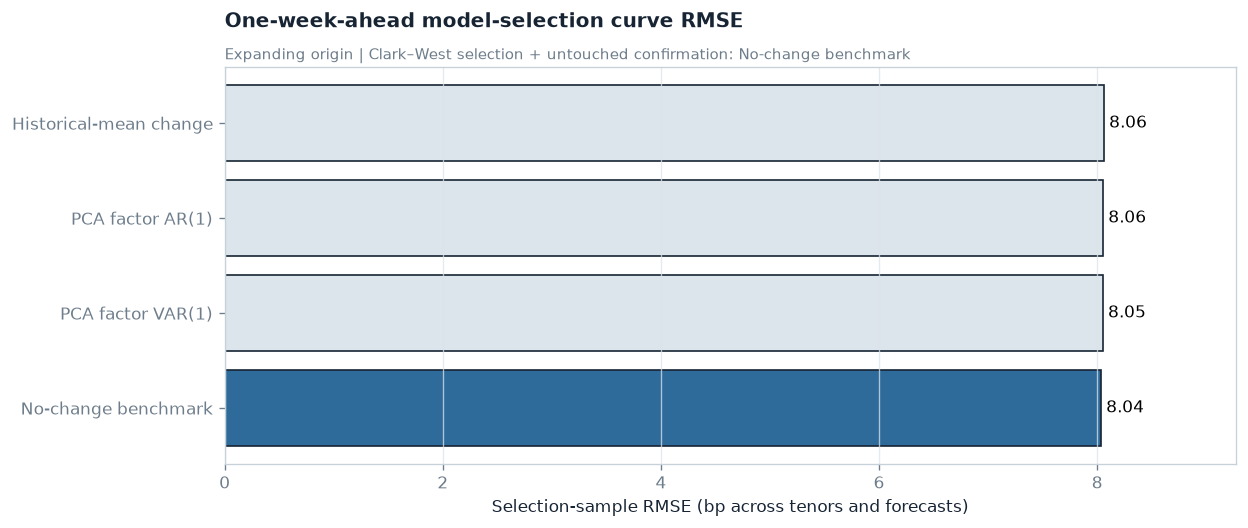

Forecast statistic,Point forecast,80% lower,80% upper,95% lower,95% upper
3M,3.640%,3.590%,3.740%,3.515%,3.846%
6M,3.580%,3.529%,3.670%,3.450%,3.775%
1Y,3.490%,3.409%,3.640%,3.310%,3.765%
2Y,3.460%,3.319%,3.621%,3.205%,3.755%
3Y,3.540%,3.390%,3.711%,3.255%,3.846%
5Y,3.680%,3.519%,3.851%,3.380%,3.966%
7Y,3.890%,3.740%,4.060%,3.600%,4.165%
10Y,4.140%,3.990%,4.301%,3.875%,4.390%
20Y,4.760%,4.629%,4.910%,4.545%,5.001%


**Inference limitation:** the 260-week bootstrap challenge preserves weekly cross-tenor dependence and challenges serial dependence across 3 block lengths, but assumes local stationarity and circular wrap. Wilson and IID-binomial fields are auxiliary only. This evaluation sample has low familywise power to certify a 3 pp non-inferiority margin; INCONCLUSIVE is therefore escalated rather than treated as PASS.

In [13]:
if RESULT.forecast is None:
    display(Markdown(f"**Forecast status:** {RESULT.forecast_note}"))
else:
    forecast = RESULT.forecast
    partition_summary = pd.DataFrame(
        [
            {
                "Evaluation partition": label,
                "Start": frame.index.min(),
                "End": frame.index.max(),
                "Observations": len(frame),
                "Maximum training end": frame["Training end"].max(),
            }
            for label, frame in forecast.audit_trail.groupby(
                "Evaluation partition", sort=False
            )
        ]
    ).set_index("Evaluation partition")
    display(Markdown(
        f"**Forecast timing:** as-of **{forecast.forecast_as_of.date()}** → target weekly "
        f"period end **{forecast.target_period_end.date()}**. This target is historical/stale, "
        "not a current trading or management forecast."
    ))
    display(format_table(
        partition_summary,
        formats={"Observations": "{:,.0f}"},
        caption="Disjoint adoption and interval-evaluation partitions | every training end < target",
    ))
    display(format_table(
        forecast.model_comparison,
        formats={
            "Selection curve RMSE (bp)": "{:.4f}",
            "Selection RMSE improvement vs no-change": "{:+.3%}",
            "Mean weekly squared-loss advantage": "{:+.4f}",
            "HAC statistic": "{:+.3f}",
            "Two-sided p-value": "{:.4f}",
            "Clark-West adjusted advantage": "{:+.4f}",
            "Clark-West HAC statistic": "{:+.3f}",
            "Clark-West one-sided p-value": "{:.4f}",
            "Multiplicity-adjusted alpha": "{:.4f}",
            "Confirmation curve RMSE (bp)": "{:.4f}",
            "Confirmation RMSE improvement": "{:+.3%}",
            "Confirmation Clark-West one-sided p-value": "{:.4f}",
        },
        caption=(
            "Expanding-origin selection and chronologically held-out confirmation | "
            "interval evaluation is not used for model adoption"
        ),
    ))
    fig = plot_forecast_rmse(forecast)
    display(fig)
    plt.close(fig)

    display(format_table(
        forecast.prediction_intervals_pct.T,
        formats="{:.3f}%",
        caption=(
            f"Historical next-period curve forecast as of {forecast.forecast_as_of.date()} "
            f"for {forecast.target_period_end.date()} | fallback: {forecast.selected_model}"
        ),
    ))
    coverage_columns = [
        "Hits", "Evaluated forecasts", "Observed coverage", "Coverage gap",
        "Acceptable coverage floor", "Hit lag-1 autocorrelation",
        "Familywise block-bootstrap coverage lower bound",
        "Familywise block-bootstrap coverage upper bound", "Status",
    ]
    coverage_formats = {
        "Hits": "{:,.0f}", "Evaluated forecasts": "{:,.0f}",
        "Observed coverage": "{:.1%}", "Coverage gap": "{:+.1%}",
        "Acceptable coverage floor": "{:.1%}", "Hit lag-1 autocorrelation": "{:+.3f}",
        "Familywise block-bootstrap coverage lower bound": "{:.1%}",
        "Familywise block-bootstrap coverage upper bound": "{:.1%}",
    }
    interval_observations = int(forecast.interval_coverage["Evaluated forecasts"].min())
    bootstrap_replications = int(forecast.interval_coverage["Bootstrap replications"].min())
    bootstrap_blocks = str(forecast.interval_coverage["Bootstrap block lengths"].iloc[0])
    bootstrap_block_count = len(CONFIG.forecast.interval_bootstrap_block_lengths)
    inference_family = len(forecast.interval_coverage)
    display(format_table(
        forecast.interval_coverage[coverage_columns],
        formats=coverage_formats,
        caption=(
            f"Independent {interval_observations}-week marginal-tenor coverage challenge | "
            f"{bootstrap_replications:,} circular moving-block replications, blocks "
            f"{bootstrap_blocks}, Bonferroni family of {inference_family}; coverage-inference "
            "bounds, not a simultaneous curve band"
        ),
    ))
    display(format_table(
        forecast.full_history_interval_diagnostic[coverage_columns],
        formats=coverage_formats,
        caption=(
            "Long-history conditional/post-selection marginal coverage diagnostic | retained as "
            "contra-evidence; not an independent adoption gate"
        ),
    ))
    joint_hit_diagnostic = pd.concat(
        {
            "Independent interval evaluation": forecast.simultaneous_interval_diagnostic,
            "Conditional full history": forecast.full_history_simultaneous_diagnostic,
        },
        names=("Diagnostic sample", "Marginal nominal coverage"),
    )
    display(format_table(
        joint_hit_diagnostic,
        formats={
            "Joint hit rate of marginal tenor bands": "{:.1%}",
            "Evaluated forecasts": "{:,.0f}",
        },
        caption="Joint hit diagnostic of marginal bands—not a calibrated joint interval",
    ))
    display(Markdown(
        f"**Inference limitation:** the {interval_observations}-week bootstrap challenge "
        "preserves weekly cross-tenor dependence and "
        f"challenges serial dependence across {bootstrap_block_count} block lengths, but assumes "
        "local stationarity "
        "and circular wrap. Wilson and IID-binomial fields are auxiliary only. This evaluation sample "
        "has low familywise power to certify a 3 pp non-inferiority margin; INCONCLUSIVE is "
        "therefore escalated rather than treated as PASS."
    ))


## 6. Illustrative portfolio risk mapping


In [14]:
risk = map_linear_curve_risk(
    RESULT.data.weekly_changes_bp,
    ILLUSTRATIVE_KRD_USD_PER_BP,
    pca,
    CONFIG.risk,
    CONFIG.pca.retained_factors,
)
recency_weighted_risk = map_linear_curve_risk(
    RESULT.data.weekly_changes_bp,
    ILLUSTRATIVE_KRD_USD_PER_BP,
    RESULT.current_ewma_pca,
    CONFIG.risk,
    CONFIG.pca.retained_factors,
)
display(Markdown(
    "**Important:** the KRD below is a transparent demonstration input, not the user's position, "
    "not a limit, and not a trade recommendation. Any external KRD must first pass same-curve, "
    "as-of, portfolio lineage, sensitivity-engine, official-position, and organizational approval controls."
))
display(format_table(risk.key_rate_dv01_usd_per_bp.to_frame(), formats="${:,.0f}", caption="Illustrative key-rate DV01"))
display(format_table(risk.factor_exposure_usd_per_score.to_frame(), formats="${:,.0f}", caption="PCA factor exposure"))
display(format_table(
    pd.DataFrame(
        {
            "Structural": risk.factor_exposure_usd_per_score,
            "Recency-weighted EWMA": recency_weighted_risk.factor_exposure_usd_per_score,
        }
    ),
    formats="${:,.0f}",
    caption=(
        f"Structural versus recency-weighted exposure as of {RESULT.data.weekly_yields_pct.index.max().date()} "
        "(calibration-specific factor coordinates)"
    ),
))
display(format_table(
    risk.variance_reconciliation,
    formats={"Variance (USD²)": "${:,.0f}", "Variance share": "{:.2%}"},
    caption="Factor and residual linear-variance reconciliation",
))
risk_calibration = pd.DataFrame(
    {
        "Modeled variance (USD²)": {
            "Structural covariance": risk.variance_reconciliation.loc["Total", "Variance (USD²)"],
            "Current EWMA covariance": recency_weighted_risk.variance_reconciliation.loc["Total", "Variance (USD²)"],
        }
    }
)
risk_calibration["Weekly modeled volatility (USD)"] = np.sqrt(
    risk_calibration["Modeled variance (USD²)"]
)
risk_calibration["Ratio to structural"] = (
    risk_calibration["Weekly modeled volatility (USD)"]
    / risk_calibration.loc["Structural covariance", "Weekly modeled volatility (USD)"]
)
display(format_table(
    risk_calibration,
    formats={
        "Modeled variance (USD²)": "${:,.0f}",
        "Weekly modeled volatility (USD)": "${:,.0f}",
        "Ratio to structural": "{:.4f}",
    },
    caption="Illustrative KRD absolute structural versus recency-weighted risk",
))
tail_diagnostic = pd.concat(
    [risk.tail_risk_summary, risk.full_history_tail_risk_summary],
    keys=["Recent configured window", "Full available history"],
    names=["History scope", "Measure"],
)
display(format_table(
    tail_diagnostic,
    formats={"Confidence": "{:.1%}", "Loss (USD)": "${:,.0f}", "Effective tail mass": "{:.1f}", "History weeks": "{:,.0f}"},
    caption=(
        "Illustrative recent and full-history weekly linear tail loss—finite-sample "
        "predictive VaR convention; not regulatory VaR/ES"
    ),
))
exception_dates = risk.var_backtest_detail.loc[
    risk.var_backtest_detail["Exception"],
    ["Estimation start", "Estimation end", "Historical VaR (USD)", "Realized loss (USD)"],
]
display(format_table(
    exception_dates,
    formats={"Historical VaR (USD)": "${:,.0f}", "Realized loss (USD)": "${:,.0f}"},
    caption="Fixed-KRD exception dates | concentration by regime remains visible despite aggregate test PASS",
))
display(Markdown(
    "**Use boundary:** this is a fixed illustrative KRD applied to a single latest-revised history. "
    "It is not an actual-position, official-P&L, hypothetical-P&L, ES, PLA, or FRTB backtest. "
    "It omits convexity, options, spreads, basis, volatility, liquidity, funding, and cross-curve risk."
))
display(format_table(
    risk.var_backtest_summary,
    formats={
        "Confidence": "{:.1%}", "Expected exceptions": "{:.2f}",
        "Observed exception rate": "{:.2%}", "Kupiec p-value": "{:.4f}",
        "Christoffersen independence p-value": "{:.4f}",
        "Conditional coverage p-value": "{:.4f}",
    },
    caption=(
        "Rolling VaR diagnostic with fixed illustrative KRD and latest-revised linear scenario "
        "P&L—not actual-position/official-P&L backtesting"
    ),
))
recent_tail_statuses = set(risk.tail_risk_summary["Tail-mass review status"])
rolling_var_status = str(
    risk.var_backtest_summary.loc["Rolling historical VaR", "Status"]
)
illustrative_krd_evidence_status = (
    "SHARE WITH CAVEATS"
    if rolling_var_status == "PASS" and recent_tail_statuses == {"REVIEW LEVEL MET"}
    else "NEEDS REVISION"
)
illustrative_krd_evidence_reason = (
    "Recent VaR/ES tail-mass review level is not met"
    if illustrative_krd_evidence_status == "NEEDS REVISION"
    else "Statistical evidence gate met; external lineage and approval remain absent"
)
display(Markdown(
    f"### Illustrative fixed-KRD evidence gate: **{illustrative_krd_evidence_status}**\n\n"
    "This gate uses the rolling VaR status and every recent-window VaR/ES tail-mass "
    "status. It is separate from the repository-scope technical disposition and is "
    "necessary but not sufficient for any organizational use approval. "
    f"Observed reason: {illustrative_krd_evidence_reason}."
))


**Important:** the KRD below is a transparent demonstration input, not the user's position, not a limit, and not a trade recommendation. Any external KRD must first pass same-curve, as-of, portfolio lineage, sensitivity-engine, official-position, and organizational approval controls.

,DV01 (USD per bp fall in yield)
3M,$0
6M,$0
1Y,"$25,000"
2Y,"$100,000"
3Y,"$150,000"
5Y,"$200,000"
7Y,"$150,000"
10Y,"$100,000"
20Y,"$50,000"


,USD per factor-score unit
PC1 — Level,"$-303,868"
PC2 — Slope,"$-51,807"
PC3 — Curvature,"$-72,690"


,Structural,Recency-weighted EWMA
PC1 — Level,"$-303,868","$-305,491"
PC2 — Slope,"$-51,807","$-45,558"
PC3 — Curvature,"$-72,690","$-62,971"


,Variance (USD²),Variance share
Risk source,,
PC1 — Level,"$81,412,831,064,733",98.98%
PC2 — Slope,"$427,640,628,845",0.52%
PC3 — Curvature,"$312,871,274,548",0.38%
Residual key-rate risk,"$100,146,183,192",0.12%
Total,"$82,253,489,151,319",100.00%


,Modeled variance (USD²),Weekly modeled volatility (USD),Ratio to structural
Structural covariance,"$82,253,489,151,319","$9,069,371",1.0000
Current EWMA covariance,"$90,169,722,663,204","$9,495,774",1.0470


,Estimation start,Estimation end,Historical VaR (USD),Realized loss (USD)
Observation date,,,,
2019-09-13 00:00:00,2009-09-25 00:00:00,2019-09-06 00:00:00,"$20,725,000","$24,225,000"
2022-03-11 00:00:00,2012-03-23 00:00:00,2022-03-04 00:00:00,"$18,575,000","$21,825,000"
2022-03-25 00:00:00,2012-04-06 00:00:00,2022-03-18 00:00:00,"$20,000,000","$28,150,000"
2022-06-10 00:00:00,2012-06-22 00:00:00,2022-06-03 00:00:00,"$21,825,000","$22,350,000"
2022-09-23 00:00:00,2012-10-05 00:00:00,2022-09-16 00:00:00,"$22,100,000","$23,925,000"
2023-05-19 00:00:00,2013-05-31 00:00:00,2023-05-12 00:00:00,"$22,350,000","$22,575,000"
2024-10-04 00:00:00,2014-10-17 00:00:00,2024-09-27 00:00:00,"$22,350,000","$23,400,000"
2025-04-11 00:00:00,2015-04-24 00:00:00,2025-04-04 00:00:00,"$22,575,000","$30,900,000"


**Use boundary:** this is a fixed illustrative KRD applied to a single latest-revised history. It is not an actual-position, official-P&L, hypothetical-P&L, ES, PLA, or FRTB backtest. It omits convexity, options, spreads, basis, volatility, liquidity, funding, and cross-curve risk.

,History window,Initial estimation observations,Confidence,Backtest observations,Minimum backtest observations,Exceptions,Expected exceptions,Nominal expected exceptions,Finite-sample exception bound,Nominal exception probability,VaR order-statistic rank,Coverage target achievable,Quantile convention,Observed exception rate,Kupiec LR,Kupiec p-value,Christoffersen independence LR,Christoffersen independence p-value,Conditional coverage LR,Conditional coverage p-value,Test alpha,Evaluation note,Status
Backtest,,,,,,,,,,,,,,,,,,,,,,,
Rolling historical VaR,520,520,99.0%,835,250,8,8.01,8.350000,0.009597,0.010000,516,True,"ceil((n+1)*confidence), capped at n",0.96%,0.000023,0.9962,0.154966,0.6938,0.154989,0.9254,0.050000,Kupiec null uses the finite-sample continuous-case exception bound; serial dependence is challenged separately,PASS


### Illustrative fixed-KRD evidence gate: **NEEDS REVISION**

This gate uses the rolling VaR status and every recent-window VaR/ES tail-mass status. It is separate from the repository-scope technical disposition and is necessary but not sufficient for any organizational use approval. Observed reason: Recent VaR/ES tail-mass review level is not met.

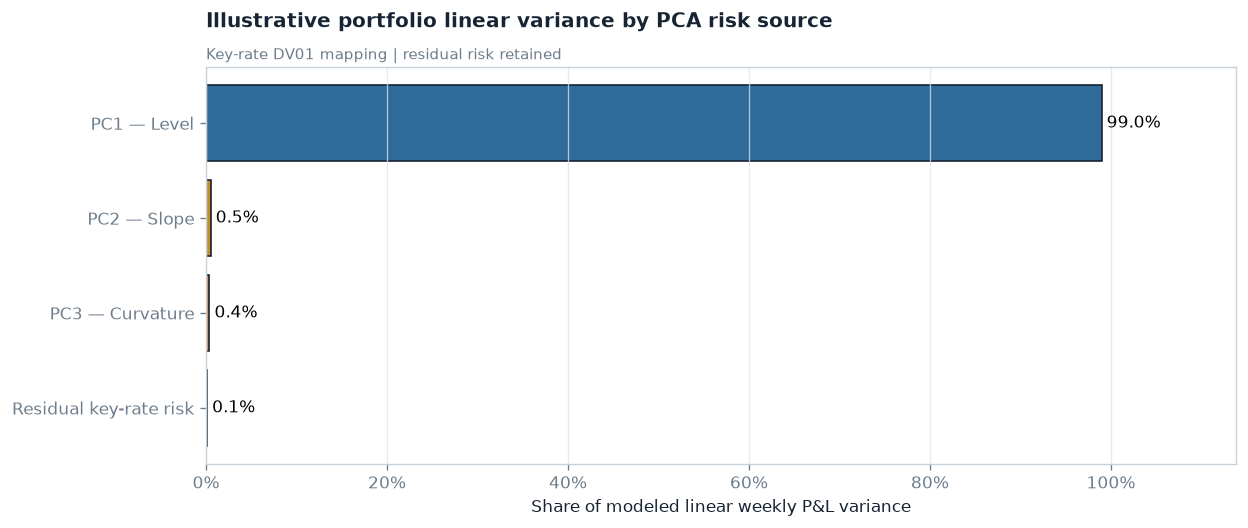

,Factor,Sigma multiple,Linear P&L (USD),3M shock (bp),2Y shock (bp),10Y shock (bp),20Y shock (bp)
Scenario,,,,,,,
PC1 — Level -1σ,PC1 — Level,-1,"$9,022,906",-3.71,-10.45,-11.59,-10.02
PC1 — Level +1σ,PC1 — Level,+1,"$-9,022,906",+3.71,+10.45,+11.59,+10.02
PC1 — Level -2σ,PC1 — Level,-2,"$18,045,812",-7.42,-20.91,-23.17,-20.03
PC1 — Level +2σ,PC1 — Level,+2,"$-18,045,812",+7.42,+20.91,+23.17,+20.03
PC1 — Level -3σ,PC1 — Level,-3,"$27,068,718",-11.13,-31.36,-34.76,-30.05
PC1 — Level +3σ,PC1 — Level,+3,"$-27,068,718",+11.13,+31.36,+34.76,+30.05
PC2 — Slope -1σ,PC2 — Slope,-1,"$653,942",+7.32,+2.51,-3.42,-4.21
PC2 — Slope +1σ,PC2 — Slope,+1,"$-653,942",-7.32,-2.51,+3.42,+4.21
PC2 — Slope -2σ,PC2 — Slope,-2,"$1,307,885",+14.65,+5.02,-6.84,-8.43


,Previous observation date,Calendar horizon (days),Linear P&L (USD),3M shock (bp),6M shock (bp),1Y shock (bp),2Y shock (bp),3Y shock (bp),5Y shock (bp),7Y shock (bp),10Y shock (bp),20Y shock (bp)
Observation date,,,,,,,,,,,,
2025-04-11 00:00:00,2025-04-04 00:00:00,7,"$-30,900,000",+6.00,+7.00,+18.00,+28.00,+32.00,+43.00,+48.00,+47.00,+47.00
2022-03-25 00:00:00,2022-03-18 00:00:00,7,"$-28,150,000",+13.00,+18.00,+38.00,+33.00,+36.00,+41.00,+39.00,+34.00,+21.00
2019-09-13 00:00:00,2019-09-06 00:00:00,7,"$-24,225,000",+0.00,+4.00,+15.00,+26.00,+30.00,+33.00,+33.00,+35.00,+34.00
2022-09-23 00:00:00,2022-09-16 00:00:00,7,"$-23,925,000",+4.00,+8.00,+19.00,+35.00,+40.00,+34.00,+29.00,+24.00,+8.00
2024-10-04 00:00:00,2024-09-27 00:00:00,7,"$-23,400,000",+5.00,+10.00,+30.00,+38.00,+35.00,+31.00,+28.00,+23.00,+18.00
2023-05-19 00:00:00,2023-05-12 00:00:00,7,"$-22,575,000",+4.00,+20.00,+27.00,+30.00,+33.00,+31.00,+29.00,+24.00,+20.00
2022-06-10 00:00:00,2022-06-03 00:00:00,7,"$-22,350,000",+18.00,+30.00,+40.00,+40.00,+34.00,+30.00,+25.00,+19.00,+12.00
2016-11-10 00:00:00,2016-11-04 00:00:00,6,"$-22,100,000",+10.00,+7.00,+10.00,+12.00,+22.00,+32.00,+37.00,+36.00,+36.00
2022-03-11 00:00:00,2022-03-04 00:00:00,7,"$-21,825,000",+6.00,+9.00,+17.00,+25.00,+29.00,+31.00,+31.00,+26.00,+22.00


,Previous observation date,Calendar horizon (days),Linear P&L (USD),3M shock (bp),6M shock (bp),1Y shock (bp),2Y shock (bp),3Y shock (bp),5Y shock (bp),7Y shock (bp),10Y shock (bp),20Y shock (bp)
Observation date,,,,,,,,,,,,
2001-11-16 00:00:00,2001-11-09 00:00:00,7,"$-47,625,000",+12.00,+24.00,+39.00,+64.00,+69.00,+62.00,+63.00,+57.00,+47.00
2008-06-13 00:00:00,2008-06-06 00:00:00,7,"$-39,150,000",+14.00,+30.00,+52.00,+65.00,+65.00,+53.00,+45.00,+33.00,+19.00
2009-06-05 00:00:00,2009-05-29 00:00:00,7,"$-33,725,000",+6.00,+5.00,+15.00,+40.00,+46.00,+51.00,+47.00,+37.00,+30.00
2001-12-07 00:00:00,2001-11-30 00:00:00,7,"$-31,150,000",-9.00,+2.00,+20.00,+35.00,+42.00,+42.00,+43.00,+42.00,+36.00
2025-04-11 00:00:00,2025-04-04 00:00:00,7,"$-30,900,000",+6.00,+7.00,+18.00,+28.00,+32.00,+43.00,+48.00,+47.00,+47.00
2002-03-08 00:00:00,2002-03-01 00:00:00,7,"$-28,800,000",+4.00,+14.00,+24.00,+42.00,+48.00,+34.00,+35.00,+35.00,+25.00
2022-03-25 00:00:00,2022-03-18 00:00:00,7,"$-28,150,000",+13.00,+18.00,+38.00,+33.00,+36.00,+41.00,+39.00,+34.00,+21.00
2008-04-18 00:00:00,2008-04-11 00:00:00,7,"$-27,675,000",+16.00,+28.00,+33.00,+43.00,+41.00,+38.00,+32.00,+28.00,+24.00
2003-03-21 00:00:00,2003-03-14 00:00:00,7,"$-26,900,000",+5.00,+6.00,+14.00,+24.00,+30.00,+40.00,+40.00,+39.00,+35.00


In [15]:
fig = plot_variance_reconciliation(risk.variance_reconciliation)
display(fig)
plt.close(fig)

scenario_columns = ["Factor", "Sigma multiple", "Linear P&L (USD)", "3M shock (bp)", "2Y shock (bp)", "10Y shock (bp)", "20Y shock (bp)"]
display(format_table(
    risk.pure_factor_scenarios[scenario_columns],
    formats={"Sigma multiple": "{:+.0f}", "Linear P&L (USD)": "${:,.0f}", **{column: "{:+.2f}" for column in scenario_columns if "shock" in column}},
    caption=(
        "Historical-covariance-scaled pure PCA factor shocks | not probability, return-period, "
        "or jointly plausible scenario statements"
    ),
))
display(format_table(
    risk.historical_scenarios.head(10),
    formats={"Linear P&L (USD)": "${:,.0f}", **{column: "{:+.2f}" for column in risk.historical_scenarios if "shock" in column}},
    caption="Worst exact contemporaneous shocks in the configured 520-week tail window",
))
display(format_table(
    risk.full_history_scenarios.head(10),
    formats={"Linear P&L (USD)": "${:,.0f}", **{column: "{:+.2f}" for column in risk.full_history_scenarios if "shock" in column}},
    caption="Worst exact contemporaneous shocks across the full available history",
))


## 7. Numerical challenge and technical disposition


In [16]:
display(Markdown(
    f"### Repository-scope technical disposition: **{RESULT.validation.overall_assessment}**\n\n"
    "This is neither organizational model approval nor management acceptance of risk. "
    "The alternate SVD/algebra route is an implementation check, not an organizationally "
    "independent model validation function."
))
display(format_table(
    RESULT.validation.algebra_checks,
    formats={"Result": "{:.4g}", "Threshold": "{:.4g}"},
    caption="Alternate-route algebra/API challenge",
))
display(format_table(
    RESULT.validation.model_health,
    formats={"Result": "{:.4f}", "Threshold": "{:.4f}"},
    caption="Model-health thresholds and required actions",
))


### Repository-scope technical disposition: **SHARE WITH CAVEATS**

This is neither organizational model approval nor management acceptance of risk. The alternate SVD/algebra route is an implementation check, not an organizationally independent model validation function.

,Result,Threshold,Status,Action
Monitor,,,,
Maximum rolling subspace angle,71.1730,30.0000,WARN,"Review regime change, eigenvalue separation, and calibration window."
Minimum aligned loading cosine,0.3935,0.8000,WARN,Do not treat rotated PC2/PC3 identities as stable limit factors.
Maximum tenor OOS reconstruction RMSE (bp),2.3783,5.0000,PASS,Retain key-rate and localized residual stresses where top-3 reconstruction is weak.
Sequential prior-window subspace angle,73.9027,30.0000,WARN,Escalate chronologically separated adjacent-window drift; this is not a historical-vintage decision replay.
Sequential prior-window minimum loading cosine,0.2833,0.8000,WARN,Do not assume a universally stable PC2/PC3 factor taxonomy.
Latest sequential subspace angle,9.2711,30.0000,PASS,"Read with the historical-worst adjacent-window result, not in isolation."
Latest sequential minimum loading cosine,0.9339,0.8000,PASS,"Read with the historical-worst adjacent-window result, not in isolation."
Treasury methodology subspace sensitivity,7.8752,15.0000,PASS,Do not attribute pre/post differences solely to market regimes.
Treasury methodology factor-volatility sensitivity,1.2785,1.2500,WARN,Review limit calibration across the source-methodology boundary.


## 8. Takeaways


In [17]:
residual_share = risk.variance_reconciliation.loc["Residual key-rate risk", "Variance share"]
selected = "not run" if RESULT.forecast is None else RESULT.forecast.selected_model
eligibility = pd.DataFrame(
    [
        ("Restricted historical research/education", "SHARE WITH CAVEATS", "Single frozen/latest-revised vintage"),
        ("Illustrative fixed-KRD linear mapping", illustrative_krd_evidence_status, illustrative_krd_evidence_reason),
        ("Fresh-feed non-limit factor/KRD monitor", "NOT ELIGIBLE", "External data, model, and use approval missing"),
        ("Factor limits / risk appetite", "NOT ELIGIBLE", "Historical factor instability breaches review levels"),
        ("Trading / hedge sizing", "NO-TRADE", "No costs, liquidity, lots, capacity, full revaluation, or OOS efficacy"),
        ("Official VaR/ES/FRTB/capital", "NOT ELIGIBLE", "Fixed illustrative KRD and non-official P&L"),
        ("Management forecast", "NOT ELIGIBLE", "No challenger edge; stale target; interval gates inconclusive"),
    ],
    columns=("Use", "Eligibility", "Blocking control"),
).set_index("Use")
display(format_table(eligibility, caption="Decision-use eligibility and hard stops"))
takeaways = f"""
1. **Use PCA as compression, not as truth.** The top three factors explain **{pca.explained_ratio[:3].sum():.2%}** of equal-tenor covariance, but factor identities rotate materially in some five-year windows.
2. **Retain key-rate residuals.** For the illustrative KRD, omitted-factor linear variance is **{residual_share:.2%}**. A different portfolio can have far higher residual concentration even when market-wide top-3 variance is high.
3. **No forecast edge is the correct possible answer.** The conservative fallback benchmark is **{selected}**; no PCA factor forecast is adopted without a statistically and economically defensible benchmark win.
4. **Separate structural and recency-weighted views.** Full-history PCA supplies a structural reference taxonomy subject to documented regime instability; EWMA is only recency-weighted relative to the frozen model date. Neither establishes stable factor limits or substitutes for stressed, liquidity-horizon, or full-revaluation risk.
5. **Escalate before any decision use.** Obtain a controlled point-in-time EOD vintage archive, correct desk curve mapping, official positions/sensitivities and P&L, nonlinear full revaluation, named owners, independent validation, approval authority, override expiry, and retention controls.
"""
display(Markdown(takeaways))
display(Markdown(
    f"**Figure lifecycle check:** open matplotlib figures after controlled display/close = "
    f"`{plt.get_fignums()}`"
))


,Eligibility,Blocking control
Use,,
Restricted historical research/education,SHARE WITH CAVEATS,Single frozen/latest-revised vintage
Illustrative fixed-KRD linear mapping,NEEDS REVISION,Recent VaR/ES tail-mass review level is not met
Fresh-feed non-limit factor/KRD monitor,NOT ELIGIBLE,"External data, model, and use approval missing"
Factor limits / risk appetite,NOT ELIGIBLE,Historical factor instability breaches review levels
Trading / hedge sizing,NO-TRADE,"No costs, liquidity, lots, capacity, full revaluation, or OOS efficacy"
Official VaR/ES/FRTB/capital,NOT ELIGIBLE,Fixed illustrative KRD and non-official P&L
Management forecast,NOT ELIGIBLE,No challenger edge; stale target; interval gates inconclusive



1. **Use PCA as compression, not as truth.** The top three factors explain **96.87%** of equal-tenor covariance, but factor identities rotate materially in some five-year windows.
2. **Retain key-rate residuals.** For the illustrative KRD, omitted-factor linear variance is **0.12%**. A different portfolio can have far higher residual concentration even when market-wide top-3 variance is high.
3. **No forecast edge is the correct possible answer.** The conservative fallback benchmark is **No-change benchmark**; no PCA factor forecast is adopted without a statistically and economically defensible benchmark win.
4. **Separate structural and recency-weighted views.** Full-history PCA supplies a structural reference taxonomy subject to documented regime instability; EWMA is only recency-weighted relative to the frozen model date. Neither establishes stable factor limits or substitutes for stressed, liquidity-horizon, or full-revaluation risk.
5. **Escalate before any decision use.** Obtain a controlled point-in-time EOD vintage archive, correct desk curve mapping, official positions/sensitivities and P&L, nonlinear full revaluation, named owners, independent validation, approval authority, override expiry, and retention controls.


**Figure lifecycle check:** open matplotlib figures after controlled display/close = `[]`

## 9. Sources, governance & hard limitations

Primary sources:

- [Federal Reserve Board — H.15 Selected Interest Rates](https://www.federalreserve.gov/releases/h15/)
- [FRED — H.15 release](https://fred.stlouisfed.org/release?rid=18)
- [U.S. Treasury — Yield Curve Methodology](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics/treasury-yield-curve-methodology)
- [Federal Reserve — Revised Guidance on Model Risk Management (2026)](https://www.federalreserve.gov/frrs/guidance/supervisory-guidance-on-model-risk-management.htm)
- [Federal Reserve SR 26-2 — Supervisory Guidance on Model Risk Management](https://www.federalreserve.gov/supervisionreg/srletters/SR2602.htm)
- [OCC Bulletin 2026-13 — Model Risk Management](https://www.occ.treas.gov/news-issuances/bulletins/2026/bulletin-2026-13.html)
- [Basel Framework — Market risk terminology](https://www.bis.org/basel_framework/chapter/MAR/10.htm)

Hard limitations:

- H.15 is latest-revised unless a frozen snapshot/vintage is used. Historical decision backtests require point-in-time archives.
- The sample spans Treasury's December 2021 curve-methodology change; the reported pre/post challenge cannot causally separate source-methodology effects from market regimes.
- Weekly covariance mixes normal holiday rolls; every actual calendar gap is retained and reported. No square-root-of-time conversion is applied.
- PCA is linear and backward-looking. Callable bonds, MBS, options, convexity, basis, volatility, funding, liquidity, and cross-curve risk require governed pricing and independently validated full revaluation.
- Historical linear VaR/ES and rolling exception tests for the fixed illustrative KRD are diagnostics only. They do not use actual historical positions or official P&L and do not implement FRTB RFET, PLA, NMRF, liquidity horizons, stressed scaling, ES calibration tests, or capital aggregation.
